In [1]:
#@title # InterPET Model Comparison -- Models #1-8 (all ablations)
# This notebook does NOT train anything. It reads the artifacts every
# individual model notebook (Model #1 .. Model #8) already saved to Google
# Drive, and compiles them into one set of comparison tables, charts, and
# an Excel workbook -- covering benchmark metrics, bootstrap CIs, CV fold
# metrics, ROC/PR/confusion/calibration/PCA/SHAP figures, and the in-silico
# mutagenesis reference-scan results (IsPETase catalytic triad).
#
# Run the cells top to bottom. Each section is defensive about missing
# files -- if a given model hasn't produced a particular artifact yet, that
# section just skips/greys out that model and prints a warning, instead of
# crashing the whole notebook.
#
#   1. 1D, ESM-2, XGBoost
#   2. 1D, ESM-2, RF
#   3. 1D, ProtT5, XGBoost
#   4. 1D, ProtT5, RF
#   5. 1D, AAC/CTD, XGBoost
#   6. 1D, AAC/CTD, RF
#   7. 1D Graph (ESM-2 nodes + sequence-chain edges), GraphSAGE
#   8. 1D+3D Graph (ESM-2 nodes + structure contact-map edges), GraphSAGE
#
# CAVEAT worth keeping in mind throughout: Models #1-6 are evaluated on the
# FULL curated benchmark set, while Models #7-8 are evaluated on a
# STRUCTURE-MATCHED SUBSET of it (only sequences with a resolvable 3D
# structure). Benchmark sizes are reported everywhere below so this is
# never hidden -- but it means #7/#8 vs #1-6 is not a perfectly
# apples-to-apples comparison on the benchmark metrics; #7 vs #8 IS
# apples-to-apples (same subset, same node features, only the edges differ).


In [2]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount("/content/drive")

!pip install -q openpyxl seaborn


Mounted at /content/drive


In [3]:
#@title # 1. Configuration
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

COMPARISON_OUT_DIR = os.path.join(MODELS_DIR, "comparison_all_models")
os.makedirs(COMPARISON_OUT_DIR, exist_ok=True)

# One row per model -- this is the single source of truth for the whole
# notebook. Add/remove/edit rows here if the ablation table changes.
MODELS = [
    {"id": "model1", "label": "M1: ESM-2 + XGBoost",        "dir": "model1_esm2_xgb",           "family": "1D embedding", "feature": "ESM-2",   "algorithm": "XGBoost"},
    {"id": "model2", "label": "M2: ESM-2 + RF",              "dir": "model2_esm2_rf",             "family": "1D embedding", "feature": "ESM-2",   "algorithm": "Random Forest"},
    {"id": "model3", "label": "M3: ProtT5 + XGBoost",        "dir": "model3_prott5_xgb",          "family": "1D embedding", "feature": "ProtT5",  "algorithm": "XGBoost"},
    {"id": "model4", "label": "M4: ProtT5 + RF",             "dir": "model4_prott5_rf",           "family": "1D embedding", "feature": "ProtT5",  "algorithm": "Random Forest"},
    {"id": "model5", "label": "M5: AAC/CTD + XGBoost",       "dir": "model5_aac_ctd_xgb",         "family": "1D handcrafted", "feature": "AAC/CTD", "algorithm": "XGBoost"},
    {"id": "model6", "label": "M6: AAC/CTD + RF",            "dir": "model6_aac_ctd_rf",          "family": "1D handcrafted", "feature": "AAC/CTD", "algorithm": "Random Forest"},
    {"id": "model7", "label": "M7: Graph (chain edges)",     "dir": "model7_1d_graph_chain",      "family": "Graph",        "feature": "ESM-2 nodes + chain edges",    "algorithm": "GraphSAGE"},
    {"id": "model8", "label": "M8: Graph (contact-map edges)", "dir": "model8_1d3d_graph_contact", "family": "Graph",        "feature": "ESM-2 nodes + contact-map edges", "algorithm": "GraphSAGE"},
]

for m in MODELS:
    m["out_dir"] = os.path.join(MODELS_DIR, m["dir"])

MODEL_IDS = [m["id"] for m in MODELS]
MODEL_LABELS = {m["id"]: m["label"] for m in MODELS}
LABEL_ORDER = [m["label"] for m in MODELS]

print(f"Comparing {len(MODELS)} models. Outputs will be written to:\n  {COMPARISON_OUT_DIR}")
for m in MODELS:
    exists = "OK" if os.path.isdir(m["out_dir"]) else "MISSING"
    print(f"  [{exists:7s}] {m['id']:8s} {m['out_dir']}")


Comparing 8 models. Outputs will be written to:
  /content/drive/MyDrive/InterPET/models/comparison_all_models
  [OK     ] model1   /content/drive/MyDrive/InterPET/models/model1_esm2_xgb
  [OK     ] model2   /content/drive/MyDrive/InterPET/models/model2_esm2_rf
  [OK     ] model3   /content/drive/MyDrive/InterPET/models/model3_prott5_xgb
  [OK     ] model4   /content/drive/MyDrive/InterPET/models/model4_prott5_rf
  [OK     ] model5   /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb
  [OK     ] model6   /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf
  [OK     ] model7   /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain
  [OK     ] model8   /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact


In [4]:
# Every loader below returns None (or an empty structure) instead of raising
# when a file is missing, and prints a one-line warning -- so a model that
# hasn't produced a given artifact just gets skipped in that section rather
# than crashing the whole comparison.

def _path(model, filename):
    return os.path.join(model["out_dir"], filename)


def load_csv(model, filename, **kwargs):
    p = _path(model, filename)
    if not os.path.exists(p):
        print(f"  [missing] {model['id']}: {filename}")
        return None
    try:
        return pd.read_csv(p, **kwargs)
    except Exception as e:
        print(f"  [error]   {model['id']}: {filename} -- {e}")
        return None


def load_pickle(model, filename):
    p = _path(model, filename)
    if not os.path.exists(p):
        print(f"  [missing] {model['id']}: {filename}")
        return None
    try:
        with open(p, "rb") as f:
            return pickle.load(f)
    except Exception as e:
        print(f"  [error]   {model['id']}: {filename} -- {e}")
        return None


def load_text(model, filename):
    p = _path(model, filename)
    if not os.path.exists(p):
        return None
    with open(p) as f:
        return f.read().strip()


def load_image(model, filename):
    p = _path(model, filename)
    if not os.path.exists(p):
        return None
    try:
        return mpimg.imread(p)
    except Exception:
        return None


def image_grid(filename, title, ncols=2, figsize_per=(9.0, 3.6), save_as=None,
                hspace=0.15, wspace=0.05, dpi=600):
    available = [(m, load_image(m, filename)) for m in MODELS]
    available = [(m, img) for m, img in available if img is not None]
    if not available:
        print(f"[{title}] no models have '{filename}' yet -- skipping this gallery.")
        return

    n = len(available)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, (m, img) in zip(axes, available):
        ax.imshow(img, aspect="auto")
        ax.set_title(m["label"], fontsize=11, pad=6)   # font size also increased to be proportional
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=15, y=1.0)
    plt.subplots_adjust(hspace=hspace, wspace=wspace)
    if save_as:
        fig.savefig(os.path.join(COMPARISON_OUT_DIR, save_as), dpi=dpi, bbox_inches="tight")
    plt.show()

In [5]:
#@title # 3. Benchmark metrics -- compiled table (all models)
rows = []
bench_n_by_model = {}

for m in MODELS:
    metrics = load_csv(m, "benchmark_metrics.csv", index_col=0)
    detailed = load_csv(m, "benchmark_predictions_detailed.csv")
    bench_n = len(detailed) if detailed is not None else np.nan
    bench_n_by_model[m["id"]] = bench_n

    if metrics is None:
        continue
    metric_series = metrics.iloc[:, 0]
    row = {"model": m["label"], "family": m["family"], "algorithm": m["algorithm"],
           "feature": m["feature"], "benchmark_n": bench_n}
    row.update(metric_series.to_dict())
    rows.append(row)

master_benchmark_df = pd.DataFrame(rows)
metric_cols = [c for c in ["accuracy", "precision", "recall", "f1", "auc", "pr_auc", "mcc"] if c in master_benchmark_df.columns]
master_benchmark_df = master_benchmark_df[["model", "family", "algorithm", "feature", "benchmark_n"] + metric_cols]
master_benchmark_df = master_benchmark_df.sort_values("f1", ascending=False).reset_index(drop=True)

master_benchmark_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_benchmark_metrics.csv"), index=False)
master_benchmark_df


,model,family,algorithm,feature,benchmark_n,accuracy,precision,recall,f1,auc,pr_auc,mcc
0,M1: ESM-2 + XGBoost,1D embedding,XGBoost,ESM-2,139,0.971223,0.875000,0.954545,0.913043,0.986791,0.904782,0.897058
1,M7: Graph (chain edges),Graph,GraphSAGE,ESM-2 nodes + chain edges,139,0.964029,0.840000,0.954545,0.893617,0.982517,0.854758,0.874658
2,M8: Graph (contact-map edges),Graph,GraphSAGE,ESM-2 nodes + contact-map edges,139,0.942446,0.750000,0.954545,0.840000,0.954157,0.640703,0.814234
3,M4: ProtT5 + RF,1D embedding,Random Forest,ProtT5,139,0.935252,0.709677,1.000000,0.830189,0.981352,0.845946,0.809374
4,M2: ESM-2 + RF,1D embedding,Random Forest,ESM-2,139,0.913669,0.647059,1.000000,0.785714,0.984848,0.874549,0.762033
5,M5: AAC/CTD + XGBoost,1D handcrafted,XGBoost,AAC/CTD,139,0.920863,0.703704,0.863636,0.775510,0.965812,0.774149,0.733707
6,M3: ProtT5 + XGBoost,1D embedding,XGBoost,ProtT5,139,0.906475,0.628571,1.000000,0.771930,0.981352,0.827719,0.747483
7,M6: AAC/CTD + RF,1D handcrafted,Random Forest,AAC/CTD,139,0.899281,0.633333,0.863636,0.730769,0.951437,0.715595,0.682820


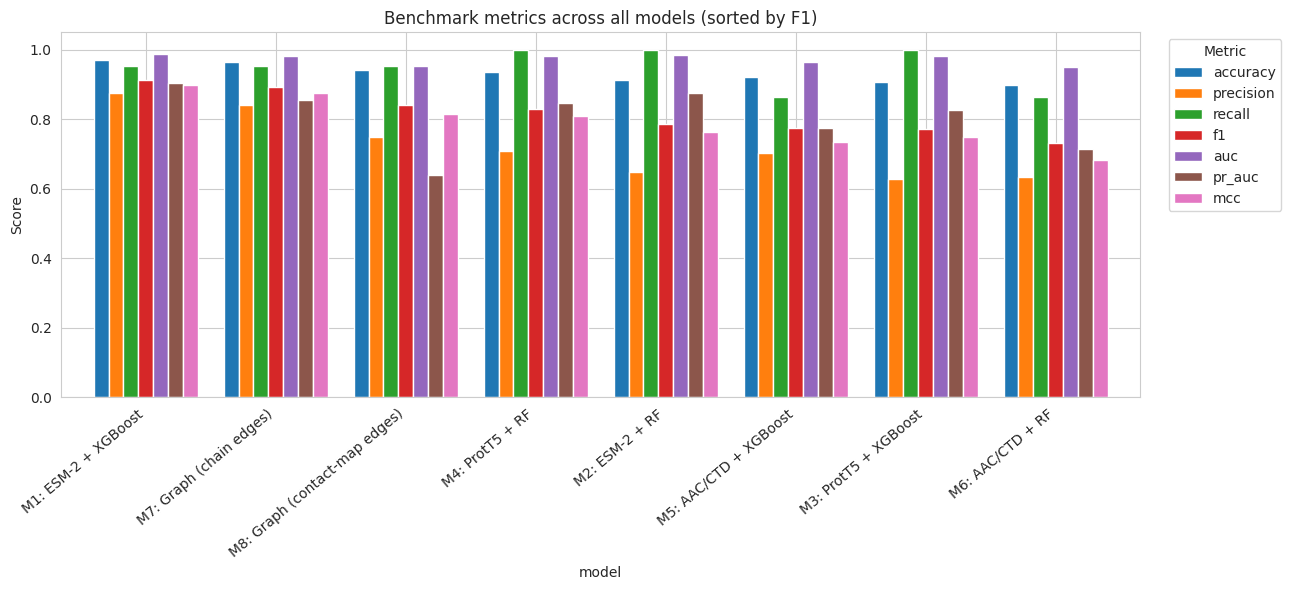

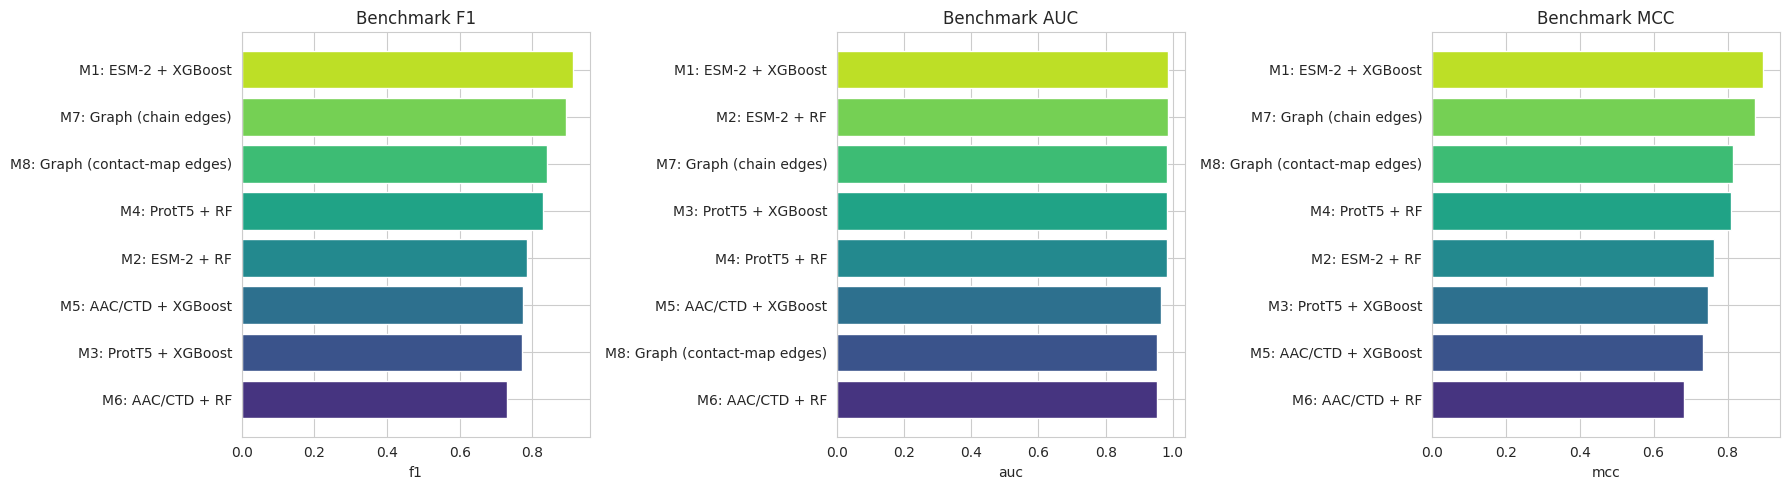

In [6]:
#@title # 4. Benchmark metrics -- comparison charts
plot_df = master_benchmark_df.set_index("model")[metric_cols]

fig, ax = plt.subplots(figsize=(13, 6))
plot_df.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Score")
ax.set_title("Benchmark metrics across all models (sorted by F1)")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(plot_df.index, rotation=40, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_OUT_DIR, "benchmark_metrics_grouped_bar.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["f1", "auc", "mcc"]):
    if metric not in plot_df.columns:
        ax.axis("off")
        continue
    sorted_vals = plot_df[metric].sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(sorted_vals)))
    ax.barh(sorted_vals.index, sorted_vals.values, color=colors)
    ax.set_title(f"Benchmark {metric.upper()}")
    ax.set_xlabel(metric)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_OUT_DIR, "benchmark_f1_auc_mcc_ranked.png"), dpi=150)
plt.show()


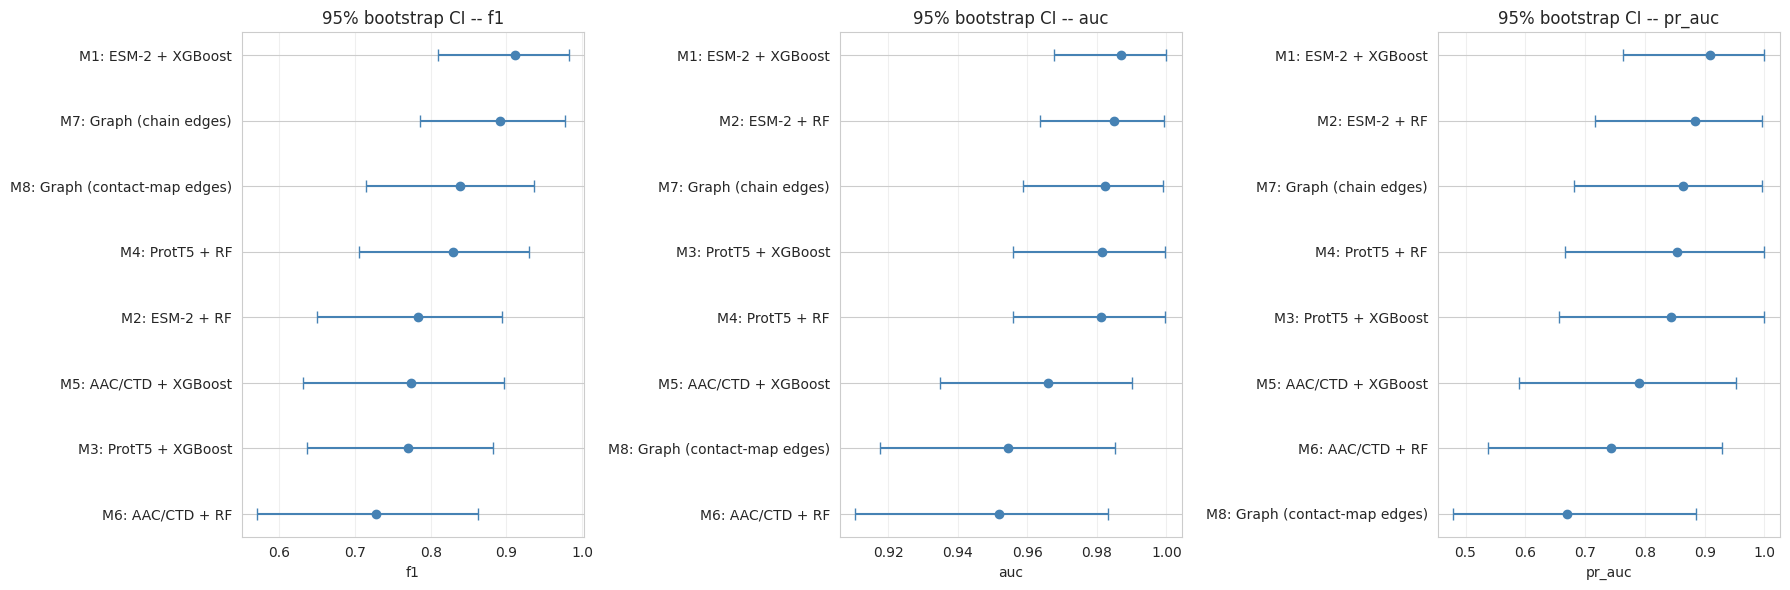

,model,metric,mean,ci_low,ci_high
0,M1: ESM-2 + XGBoost,f1,0.910723,0.809524,0.981818
1,M1: ESM-2 + XGBoost,precision,0.874987,0.730682,1.000000
2,M1: ESM-2 + XGBoost,recall,0.953537,0.833333,1.000000
3,M1: ESM-2 + XGBoost,auc,0.986881,0.967540,1.000000
4,M1: ESM-2 + XGBoost,pr_auc,0.909119,0.764154,1.000000
5,M2: ESM-2 + RF,f1,0.783821,0.649821,0.893665
6,M2: ESM-2 + RF,precision,0.648794,0.481287,0.807770
7,M2: ESM-2 + RF,recall,1.000000,1.000000,1.000000
8,M2: ESM-2 + RF,auc,0.984953,0.963594,0.999300
9,M2: ESM-2 + RF,pr_auc,0.884258,0.716861,0.996734


In [7]:
#@title # 5. Bootstrap 95% confidence intervals -- comparison (forest plot)
ci_rows = []
for m in MODELS:
    ci = load_csv(m, "benchmark_metrics_bootstrap_ci.csv", index_col=0)
    if ci is None:
        continue
    for metric_name, r in ci.iterrows():
        ci_rows.append({"model": m["label"], "metric": metric_name,
                         "mean": r["mean"], "ci_low": r["ci_low"], "ci_high": r["ci_high"]})

master_ci_df = pd.DataFrame(ci_rows)
master_ci_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_bootstrap_ci.csv"), index=False)

if not master_ci_df.empty:
    metrics_present = [m_ for m_ in ["f1", "auc", "pr_auc"] if m_ in master_ci_df["metric"].unique()]
    fig, axes = plt.subplots(1, len(metrics_present), figsize=(6 * len(metrics_present), 6), sharey=False)
    if len(metrics_present) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_present):
        sub = master_ci_df[master_ci_df["metric"] == metric].sort_values("mean")
        y_pos = np.arange(len(sub))
        err_low = sub["mean"] - sub["ci_low"]
        err_high = sub["ci_high"] - sub["mean"]
        ax.errorbar(sub["mean"], y_pos, xerr=[err_low, err_high], fmt="o", capsize=4, color="steelblue")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(sub["model"])
        ax.set_xlabel(metric)
        ax.set_title(f"95% bootstrap CI -- {metric}")
        ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_OUT_DIR, "bootstrap_ci_forest_plot.png"), dpi=150)
    plt.show()
else:
    print("No bootstrap CI files found yet for any model.")

master_ci_df


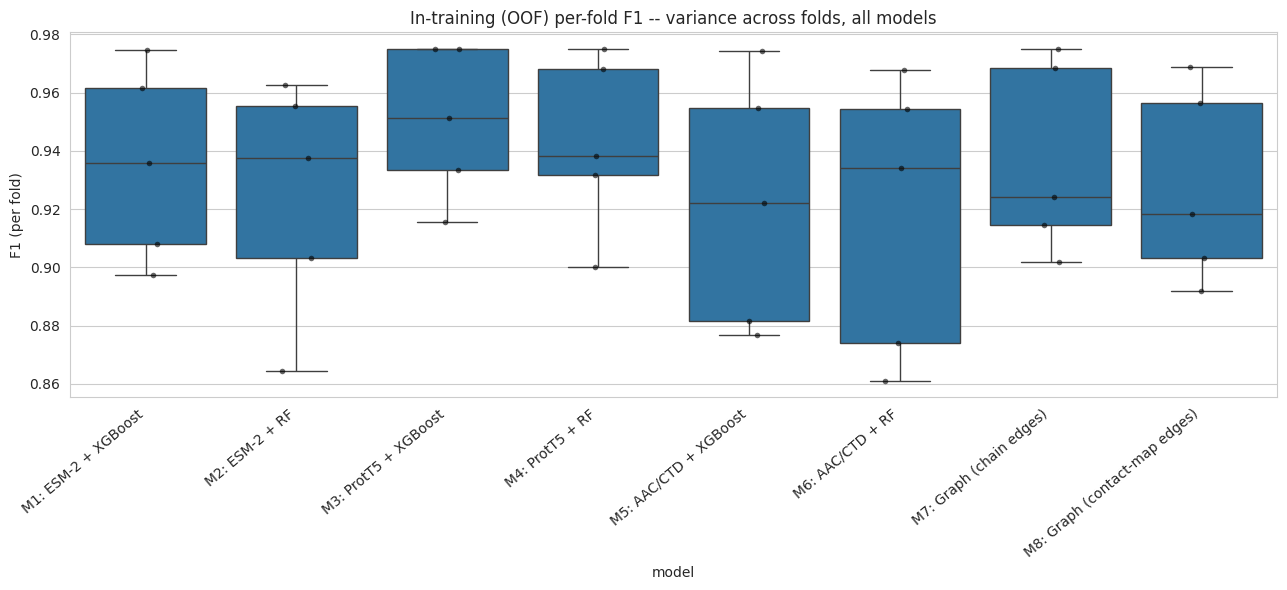

,mean,std
model,,
M1: ESM-2 + XGBoost,0.935490,0.033258
M2: ESM-2 + RF,0.924631,0.040679
M3: ProtT5 + XGBoost,0.950043,0.026021
M4: ProtT5 + RF,0.942620,0.030230
M5: AAC/CTD + XGBoost,0.921913,0.043315
M6: AAC/CTD + RF,0.918297,0.047979
M7: Graph (chain edges),0.936840,0.032921
M8: Graph (contact-map edges),0.927730,0.033596


In [8]:
#@title # 6. Cross-validation fold metrics -- comparison (boxplot)
cv_rows = []
for m in MODELS:
    cv = load_csv(m, "cv_fold_metrics.csv")
    if cv is None:
        continue
    cv = cv.copy()
    cv["model"] = m["label"]
    cv_rows.append(cv)

if cv_rows:
    master_cv_df = pd.concat(cv_rows, ignore_index=True)
    master_cv_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_cv_fold_metrics.csv"), index=False)

    fig, ax = plt.subplots(figsize=(13, 6))
    present_order = [l for l in LABEL_ORDER if l in master_cv_df["model"].unique()]
    sns.boxplot(data=master_cv_df, x="model", y="f1", ax=ax, order=present_order)
    sns.stripplot(data=master_cv_df, x="model", y="f1", ax=ax, color="black", size=4, alpha=0.6, order=present_order)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_title("In-training (OOF) per-fold F1 -- variance across folds, all models")
    ax.set_ylabel("F1 (per fold)")
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_OUT_DIR, "cv_fold_f1_boxplot_all_models.png"), dpi=150)
    plt.show()
else:
    master_cv_df = pd.DataFrame()
    print("No cv_fold_metrics.csv files found yet for any model.")

master_cv_df.groupby("model")["f1"].agg(["mean", "std"]) if not master_cv_df.empty else None


In [9]:
#@title # 7. Hyperparameter search summary
hp_rows = []
for m in MODELS:
    hp = load_csv(m, "cv_hyperparam_search.csv")
    if hp is None:
        continue
    f1_col = "cv_f1_mean" if "cv_f1_mean" in hp.columns else None
    hp_rows.append({
        "model": m["label"],
        "n_configs_tried": len(hp),
        "best_cv_f1_mean": hp[f1_col].max() if f1_col else np.nan,
    })

hp_summary_df = pd.DataFrame(hp_rows).sort_values("best_cv_f1_mean", ascending=False).reset_index(drop=True)
hp_summary_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_hyperparam_search_summary.csv"), index=False)
hp_summary_df


,model,n_configs_tried,best_cv_f1_mean
0,M3: ProtT5 + XGBoost,5,0.945869
1,M8: Graph (contact-map edges),4,0.942133
2,M1: ESM-2 + XGBoost,5,0.934303
3,M7: Graph (chain edges),4,0.931922
4,M4: ProtT5 + RF,5,0.931786
5,M5: AAC/CTD + XGBoost,5,0.920961
6,M2: ESM-2 + RF,5,0.917494
7,M6: AAC/CTD + RF,5,0.915870


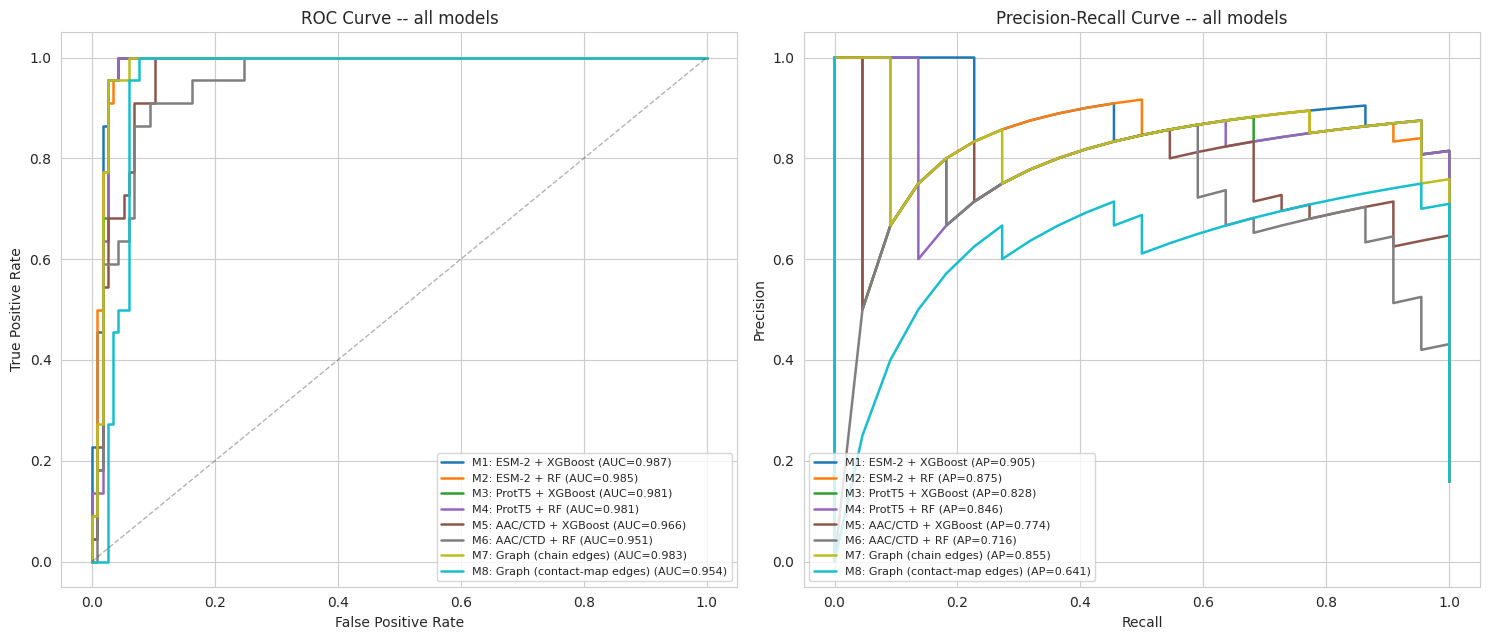

In [10]:
#@title # 8. ROC & Precision-Recall curves -- all models overlaid
# Previously this tiled each model's own roc_pr_curves.png into an 8-panel
# gallery. Overlaying every model on ONE shared ROC axis and ONE shared PR
# axis (each with its own single legend) makes direct comparison much
# easier -- no need to visually cross-reference 8 separate small plots.
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(MODELS)))

n_plotted = 0
for m, color in zip(MODELS, colors):
    detailed = load_csv(m, "benchmark_predictions_detailed.csv")
    if detailed is None or "pred_proba" not in detailed.columns or "label" not in detailed.columns:
        continue
    y_true = detailed["label"].to_numpy()
    y_score = detailed["pred_proba"].to_numpy()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=1.8, label=f"{m['label']} (AUC={roc_auc:.3f})")

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    axes[1].plot(rec, prec, color=color, linewidth=1.8, label=f"{m['label']} (AP={pr_auc:.3f})")
    n_plotted += 1

if n_plotted == 0:
    print("No models have 'benchmark_predictions_detailed.csv' with a 'pred_proba' column yet -- skipping.")
else:
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve -- all models")
    axes[0].legend(fontsize=8, loc="lower right")

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve -- all models")
    axes[1].legend(fontsize=8, loc="lower left")

    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_OUT_DIR, "gallery_roc_pr_overlay.png"), dpi=300, bbox_inches="tight")
    plt.show()

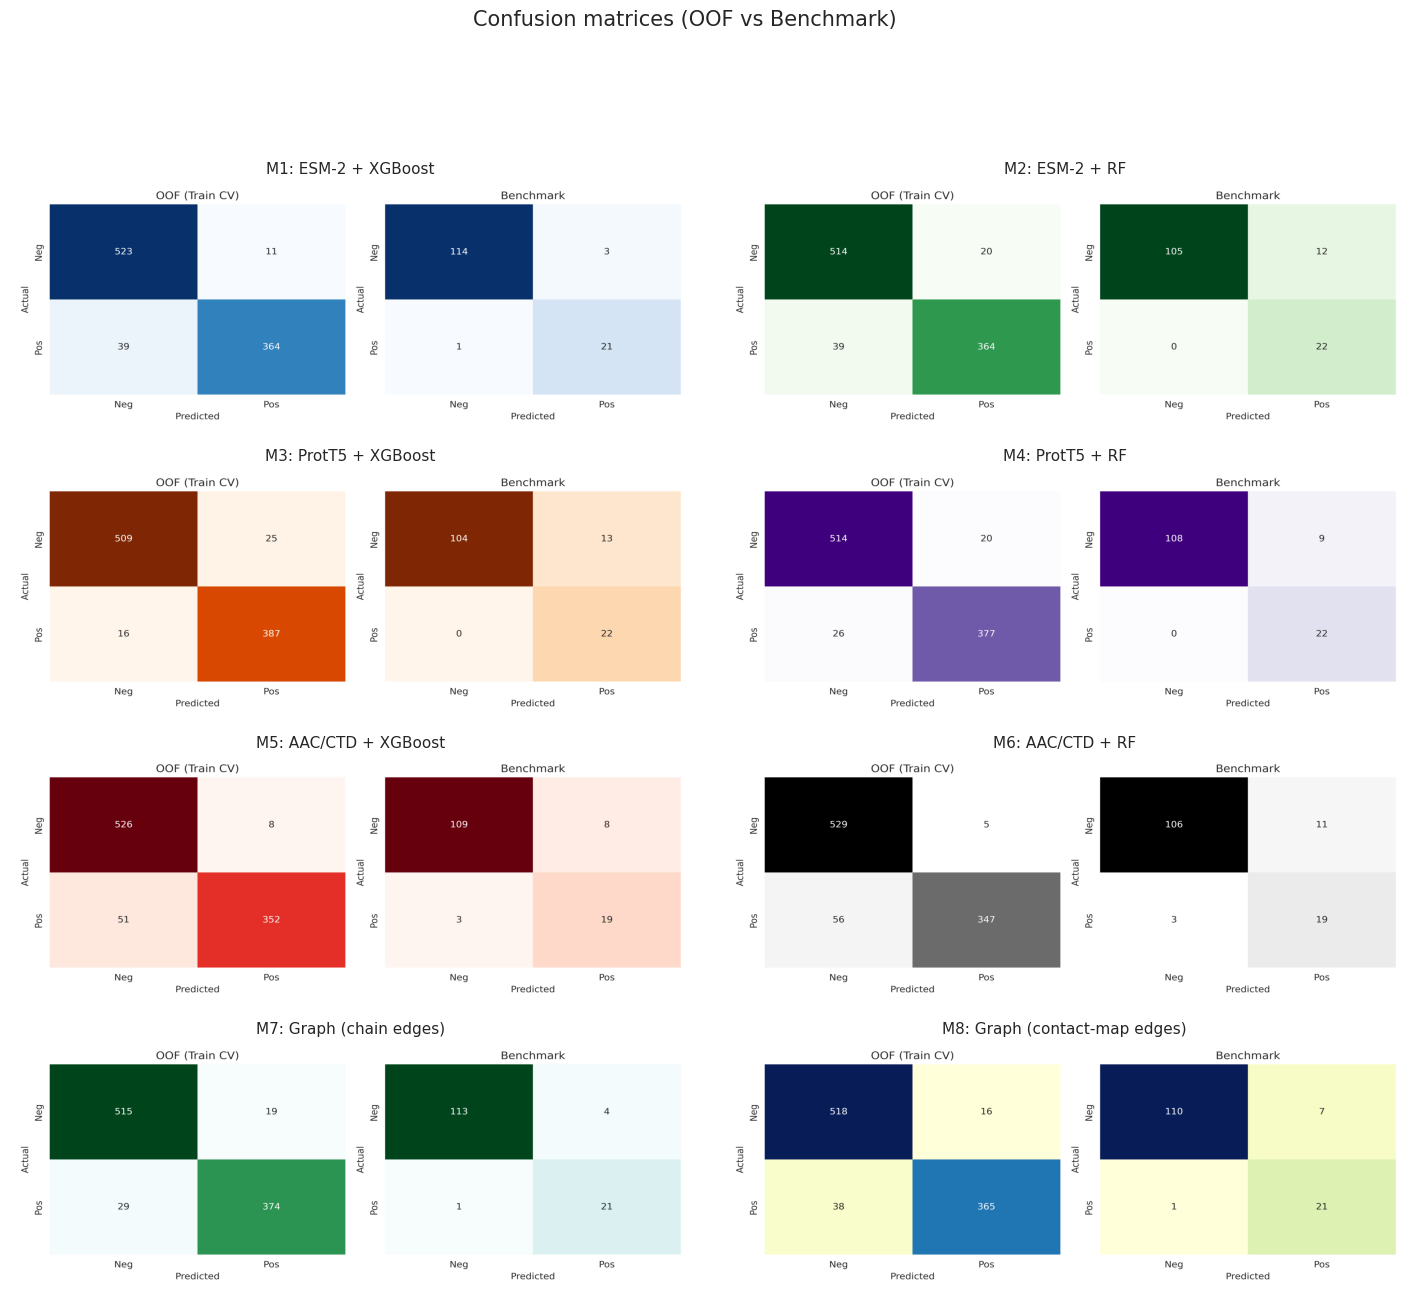

In [11]:
#@title # 9. Visual gallery -- Confusion matrices (all models)
image_grid("confusion_matrices.png", "Confusion matrices (OOF vs Benchmark)", ncols=2, save_as="gallery_confusion.png")


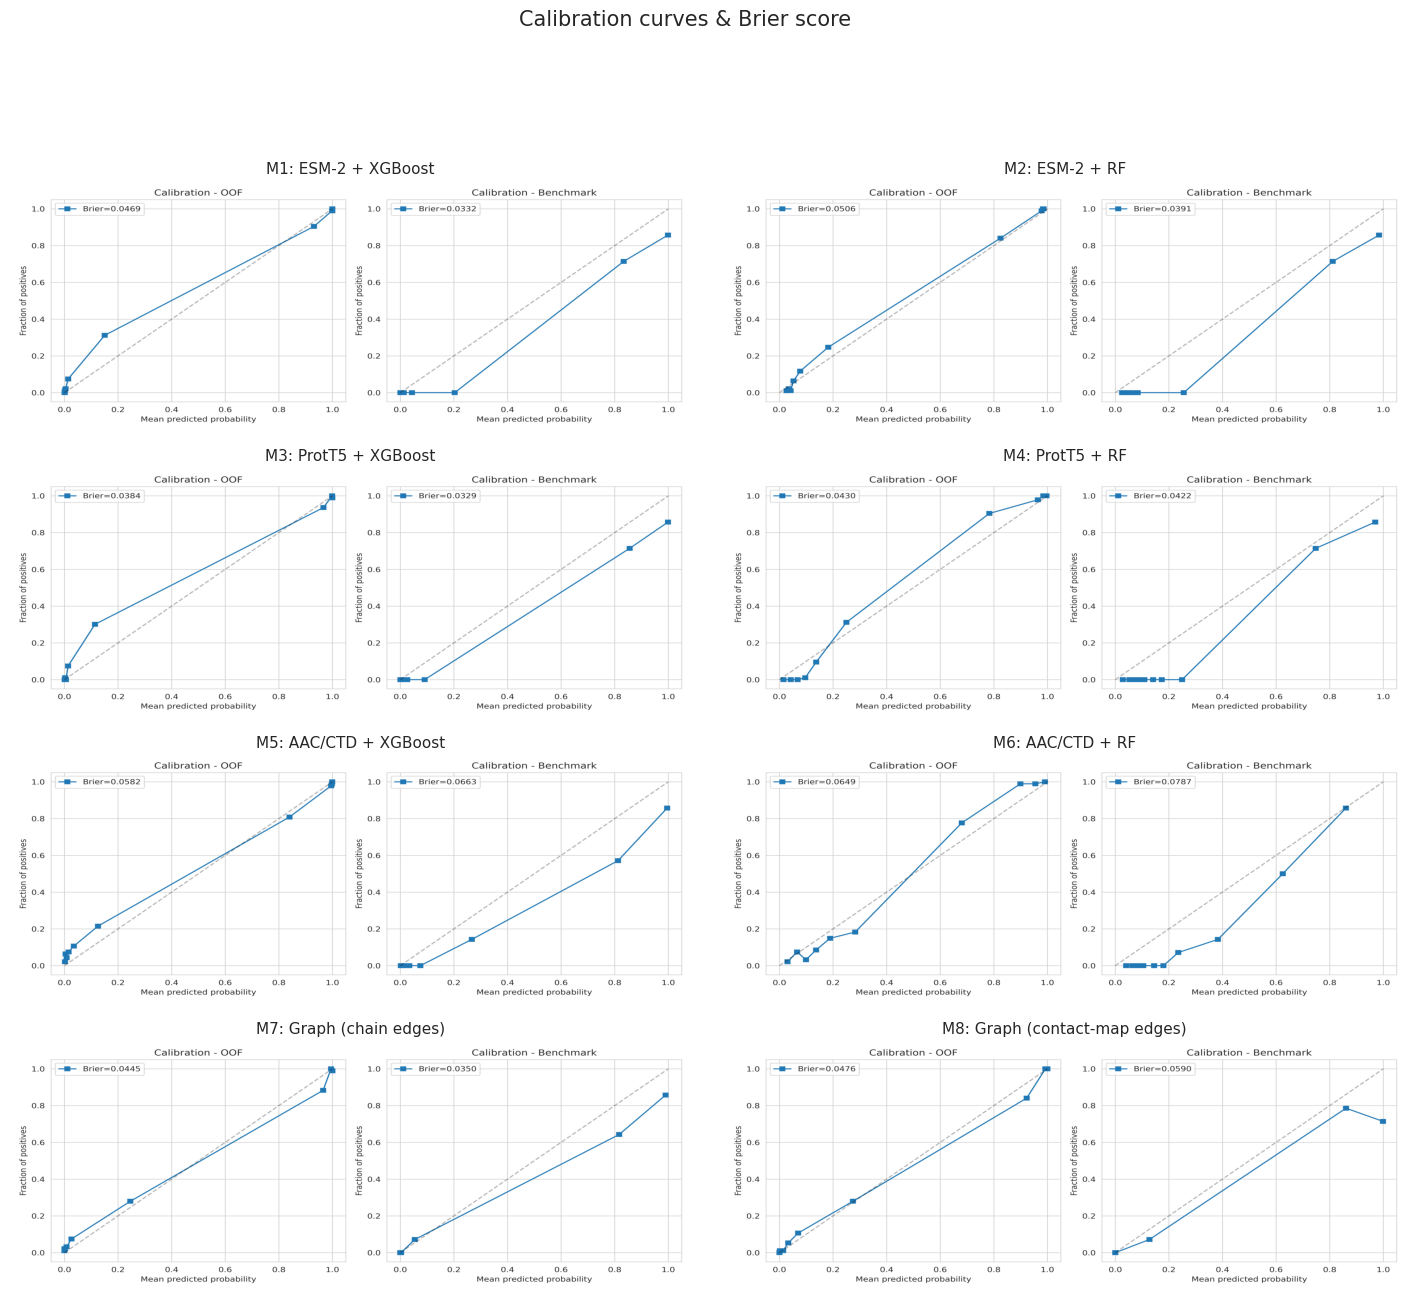

In [12]:
#@title # 10. Visual gallery -- Calibration curves (all models)
image_grid("calibration_curves.png", "Calibration curves & Brier score", ncols=2, save_as="gallery_calibration.png")


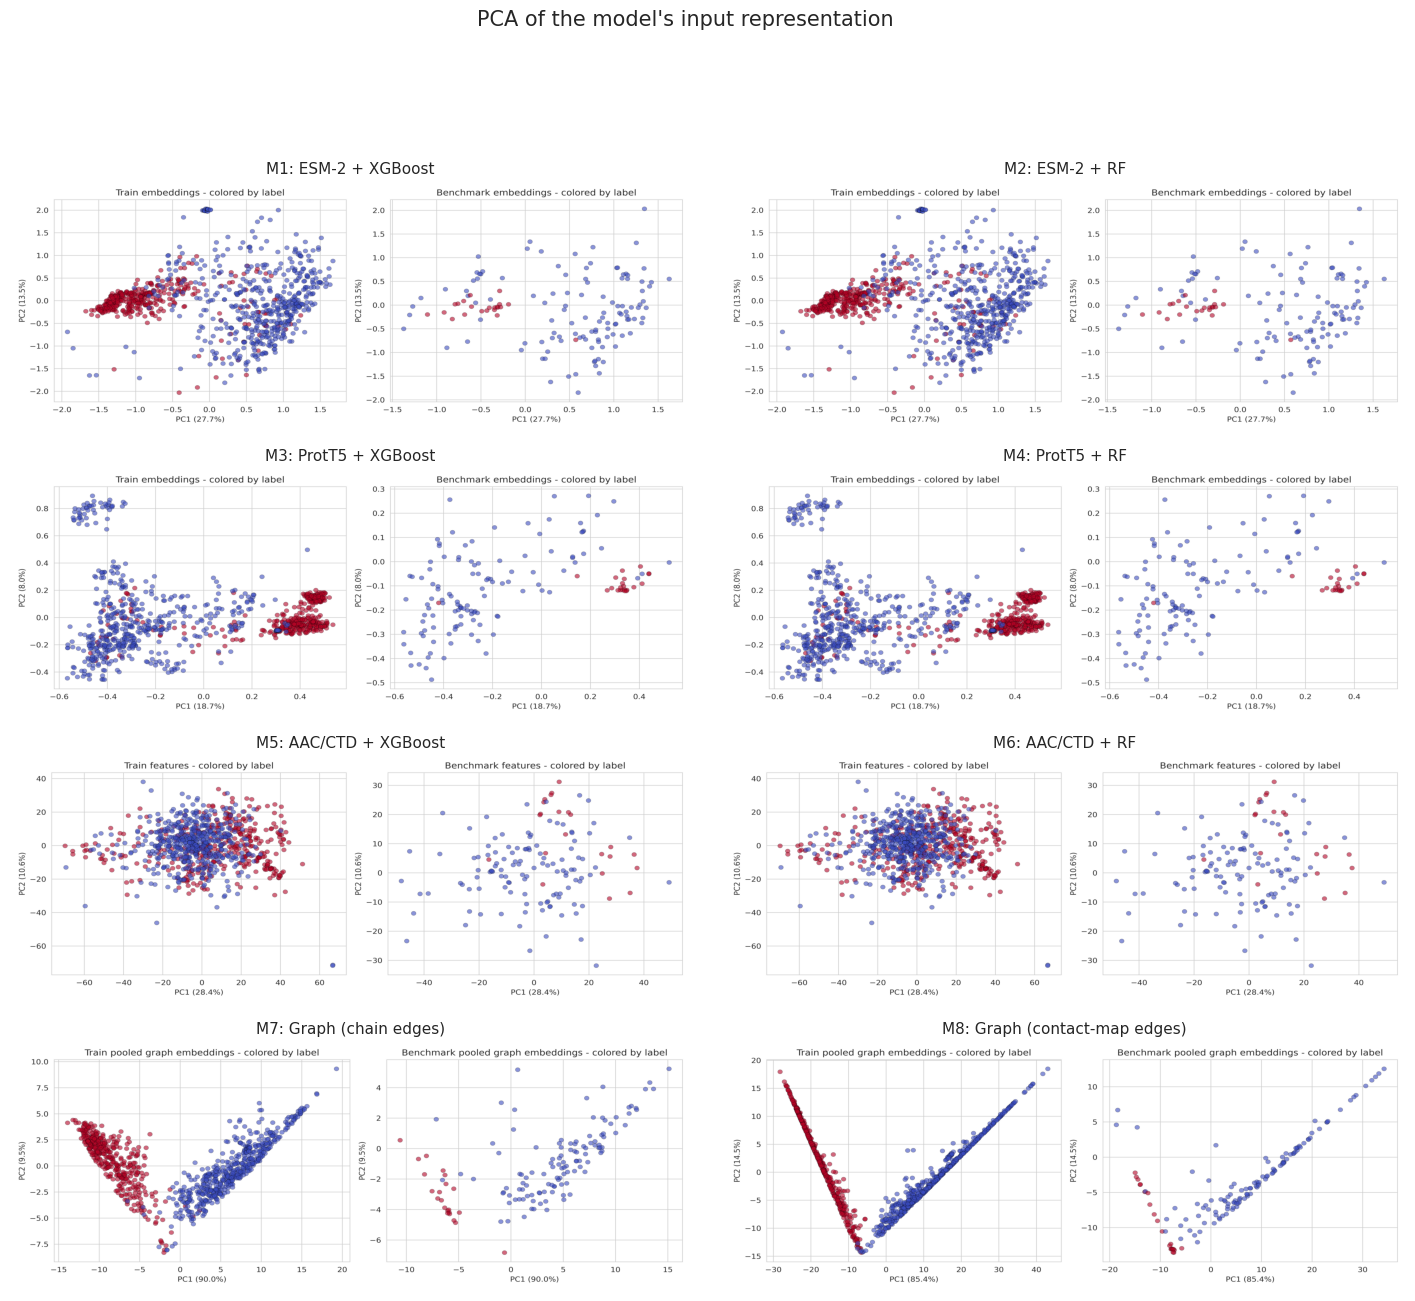

In [13]:
#@title # 11. Visual gallery -- Embedding/feature-space PCA (all models)
image_grid("embedding_pca.png", "PCA of the model's input representation", ncols=2, save_as="gallery_pca.png")

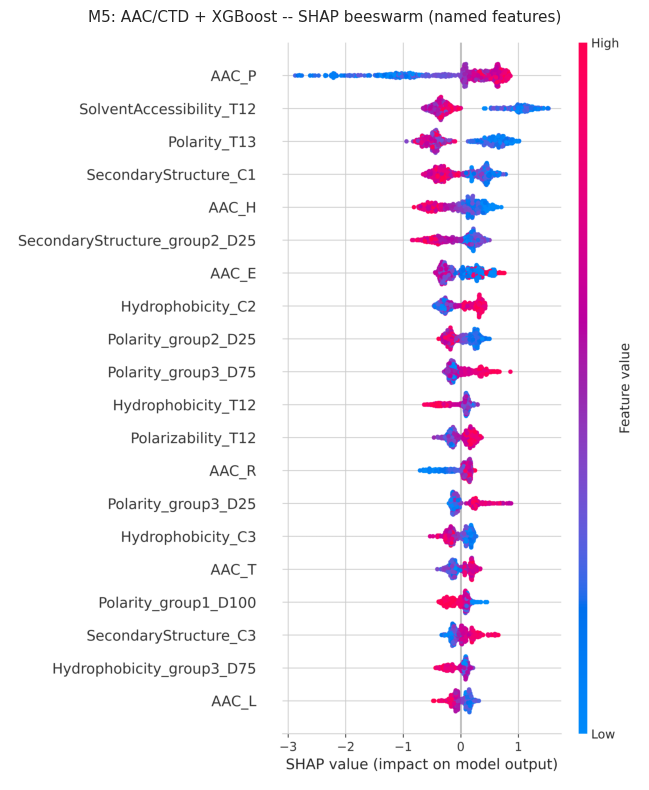

Cross-representation validation summary (full per-pair correlation tables saved separately as CSV):
                        model  n_tests  n_sig_raw_fdr  n_sig_partial_fdr  mean_abs_r_shrinkage  n_strong_matches
          M1: ESM-2 + XGBoost     3340           2596               2052              0.075995                40
         M3: ProtT5 + XGBoost     3340           2422               1949              0.063011                12
      M7: Graph (chain edges)     3340           2641               1776              0.112773                 0
M8: Graph (contact-map edges)     3340           2707               1521              0.116572                 0


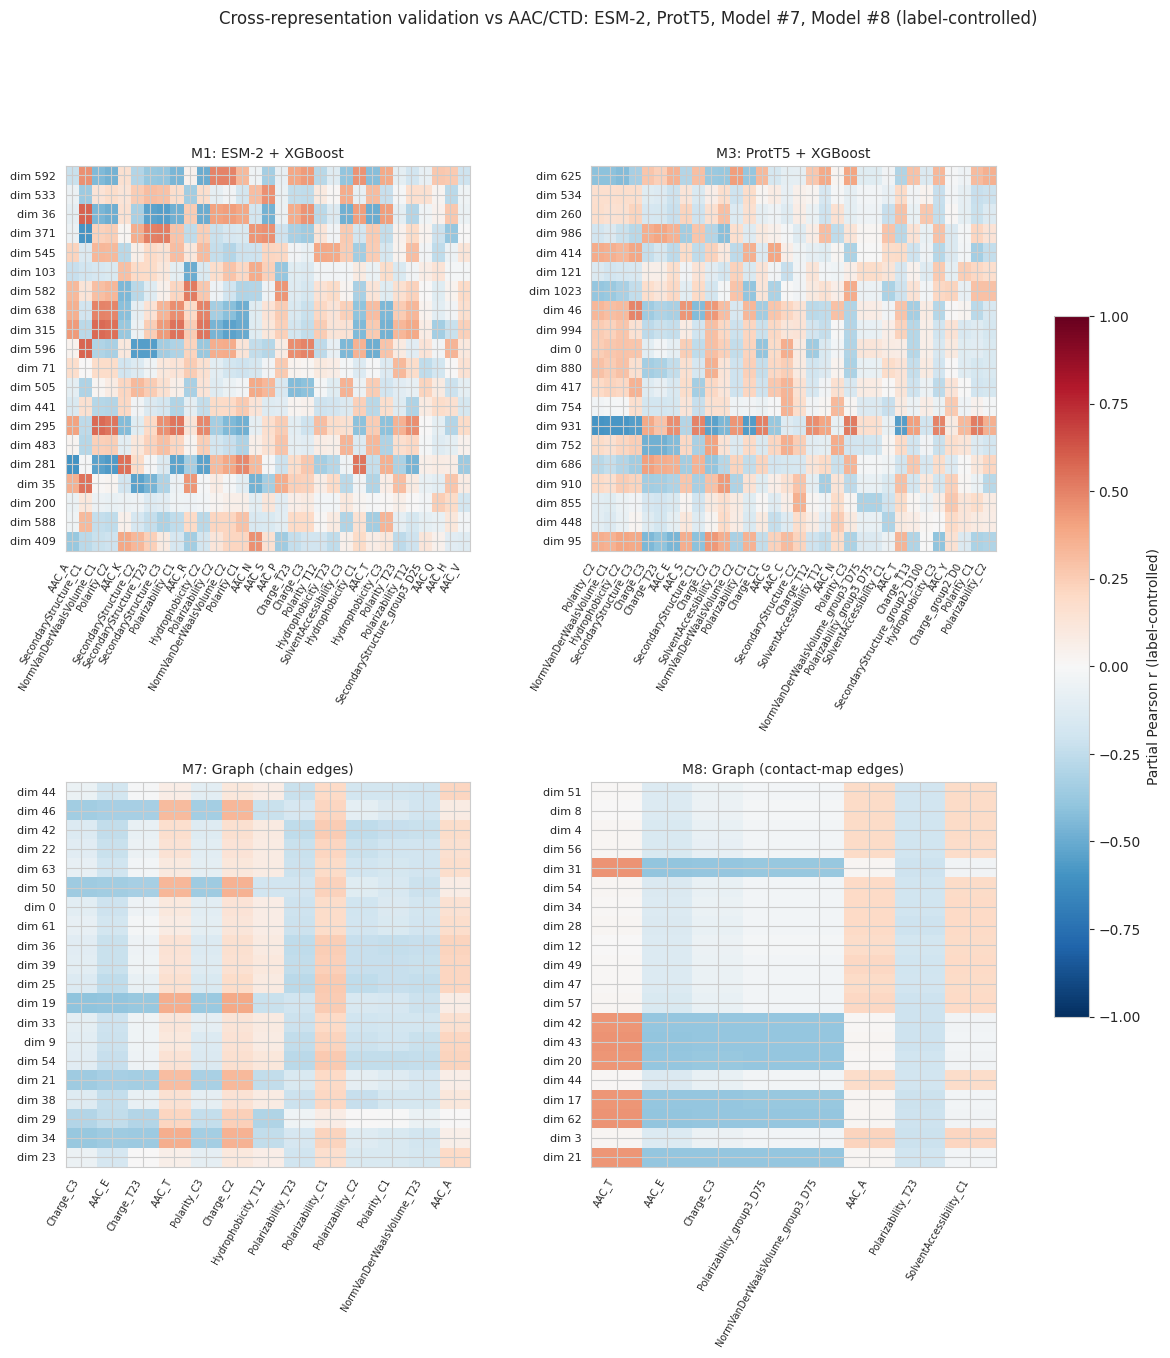

In [25]:
#@title # 12. AAC/CTD SHAP beeswarm + cross-representation heatmaps (ESM-2, ProtT5, Model #7, Model #8)
# AAC/CTD has a handful of human-readable named features, so its own
# shap.summary_plot beeswarm (saved by Model #5's own notebook) is shown as
# a standalone plot first -- that's the one representation where a beeswarm
# actually reads well.
#
# The other four representations (ESM-2, ProtT5, Model #7, Model #8) have
# hundreds of anonymous embedding dimensions, so instead each one's top-20
# SHAP dimensions (rows) are correlated against every AAC/CTD feature
# (columns) and shown as a heatmap, in a 2x2 grid. Correlations are
# label-controlled (partial correlation, removing the linear effect of the
# class label) to rule out "both representations just separately track the
# class label" as a trivial explanation for any overlap.

# ---- Part A: AAC/CTD's own SHAP beeswarm plot ----
aac_ctd_model_for_beeswarm = next(m for m in MODELS if m["id"] == "model5")
beeswarm_img = load_image(aac_ctd_model_for_beeswarm, "shap_summary_features.png")
if beeswarm_img is not None:
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(beeswarm_img, aspect="equal")
    ax.set_title(f"{aac_ctd_model_for_beeswarm['label']} -- SHAP beeswarm (named features)", fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_OUT_DIR, "gallery_aac_ctd_beeswarm.png"), dpi=600, bbox_inches="tight")
    plt.show()
else:
    print("AAC/CTD's shap_summary_features.png not found yet -- skipping the beeswarm panel.")

!pip install -q scipy statsmodels
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

AAC_CTD_MODEL_ID = "model5"
N_TOP_DIMS = 20
N_TOP_MATCHES_PER_DIM = 3
DF_TRAIN_ID_COL = "id"

aac_ctd_model = next(m for m in MODELS if m["id"] == AAC_CTD_MODEL_ID)

TRAIN_FINAL_CSV = os.path.join(PROJECT_ROOT, "datasets", "train_final_labels.csv")
if "df_train" not in globals():
    df_train = pd.read_csv(TRAIN_FINAL_CSV)


def load_npy(model, filename):
    p = _path(model, filename)
    if not os.path.exists(p):
        print(f"  [missing] {model['id']}: {filename}")
        return None
    return np.load(p)


def partial_corr_controlling_label(x, y, label):
    """Pearson correlation between x and y AFTER removing the linear effect
    of label -- isolating signals that are not merely mediated through it."""
    b_x = np.polyfit(label, x, 1)
    resid_x = x - np.polyval(b_x, label)
    b_y = np.polyfit(label, y, 1)
    resid_y = y - np.polyval(b_y, label)
    return pearsonr(resid_x, resid_y)


def cross_representation_correlation(embedding_model_id, embedding_npy_filename,
                                      shap_csv_filename="shap_top_embedding_dims.csv",
                                      dim_col="embedding_dim", emb_is_named=False,
                                      align_by_id=False, ids_filename="train_ids_all.pkl",
                                      panel_label=None):
    """
    dim_col: name of the "which dimension/feature" column in shap_csv_filename.
    emb_is_named: False (default) = dim_col holds integer column indices into
        embedding_npy_filename directly (Models #1/#3/#7/#8). True = dim_col
        holds FEATURE NAMES that must be looked up in `feature_names` to get
        a column index (used for the AAC/CTD self-comparison panel).
    align_by_id: True for Models #7/#8, whose training subset is a SUBSET of
        df_train (only sequences with valid 3D structure) -- requires an
        explicit ID-based join rather than assuming row-position alignment.
    """
    emb_model = next(m for m in MODELS if m["id"] == embedding_model_id)
    panel_label = panel_label or emb_model["label"]

    X_aac_full = load_npy(aac_ctd_model, "X_train_aac_ctd.npy")
    feature_names = load_pickle(aac_ctd_model, "feature_names.pkl")
    X_emb_full = load_npy(emb_model, embedding_npy_filename)
    shap_top_df = load_csv(emb_model, shap_csv_filename)

    if X_aac_full is None or feature_names is None or X_emb_full is None or shap_top_df is None:
        print(f"  [skip] {embedding_model_id} -- missing required artifact(s).")
        return None
    if dim_col not in shap_top_df.columns:
        print(f"  [skip] {embedding_model_id} -- no '{dim_col}' column in {shap_csv_filename}. "
              f"Available: {shap_top_df.columns.tolist()}")
        return None

    if align_by_id:
        if DF_TRAIN_ID_COL not in df_train.columns:
            print(f"  [skip] {embedding_model_id} -- df_train has no column '{DF_TRAIN_ID_COL}'.")
            return None
        emb_ids = load_pickle(emb_model, ids_filename)
        if emb_ids is None:
            return None
        df_id_to_row = {str(sid): i for i, sid in enumerate(df_train[DF_TRAIN_ID_COL])}
        emb_id_to_row = {str(sid): i for i, sid in enumerate(emb_ids)}
        common_ids = [sid for sid in emb_id_to_row if sid in df_id_to_row]
        if not common_ids:
            print(f"  [skip] {embedding_model_id} -- no overlapping ids with df_train.")
            return None
        emb_row_idx = [emb_id_to_row[sid] for sid in common_ids]
        aac_row_idx = [df_id_to_row[sid] for sid in common_ids]
        X_emb = X_emb_full[emb_row_idx]
        X_aac = X_aac_full[aac_row_idx]
        y_label = df_train["label"].astype(int).to_numpy()[aac_row_idx]
    else:
        if X_aac_full.shape[0] != X_emb_full.shape[0]:
            print(f"  [skip] {embedding_model_id} -- row count mismatch (AAC/CTD n={X_aac_full.shape[0]}, "
                  f"{embedding_model_id} n={X_emb_full.shape[0]}).")
            return None
        X_emb, X_aac = X_emb_full, X_aac_full
        y_label = df_train["label"].astype(int).to_numpy()

    top_raw = shap_top_df[dim_col].to_numpy()[:N_TOP_DIMS]
    mean_abs_shap_lookup = dict(zip(shap_top_df[dim_col], shap_top_df["mean_abs_shap"]))

    if emb_is_named:
        # top_raw holds feature NAMES -- map each to its column index in X_emb.
        name_to_idx = {name: j for j, name in enumerate(feature_names)}
        # entries: (column index into X_emb, display row label, original key for mean_abs_shap lookup)
        entries = [(name_to_idx[name], str(name), name) for name in top_raw if name in name_to_idx]
    else:
        entries = [(int(d), f"dim {int(d)}", d) for d in top_raw]

    row_labels = [e[1] for e in entries]

    rows = []
    for dim, row_label, lookup_key in entries:
        dim_values = X_emb[:, dim]
        for j, feat_name in enumerate(feature_names):
            feat_values = X_aac[:, j]
            r_raw, p_raw = pearsonr(dim_values, feat_values)
            r_partial, p_partial = partial_corr_controlling_label(dim_values, feat_values, y_label)
            rows.append({
                "row_label": row_label, "embedding_dim": dim,
                "mean_abs_shap": mean_abs_shap_lookup.get(lookup_key, np.nan),
                "aac_ctd_feature": feat_name, "pearson_r_raw": r_raw, "p_value_raw": p_raw,
                "pearson_r_partial": r_partial, "p_value_partial": p_partial,
            })

    corr_df = pd.DataFrame(rows)
    corr_df["p_adj_fdr_raw"] = multipletests(corr_df["p_value_raw"], method="fdr_bh")[1]
    corr_df["p_adj_fdr_partial"] = multipletests(corr_df["p_value_partial"], method="fdr_bh")[1]
    corr_df["shrinkage"] = corr_df["pearson_r_raw"].abs() - corr_df["pearson_r_partial"].abs()

    out_csv = os.path.join(COMPARISON_OUT_DIR, f"cross_repr_corr_{embedding_model_id}_vs_aacctd.csv")
    corr_df.to_csv(out_csv, index=False)

    relevant_features = (
        corr_df.reindex(corr_df["pearson_r_partial"].abs().sort_values(ascending=False).index)
        .groupby("row_label", sort=False).head(N_TOP_MATCHES_PER_DIM)["aac_ctd_feature"].unique()
    )
    pivot_partial = corr_df[corr_df["aac_ctd_feature"].isin(relevant_features)].pivot(
        index="row_label", columns="aac_ctd_feature", values="pearson_r_partial"
    ).reindex(row_labels)[relevant_features]

    summary = {
        "model": panel_label,
        "n_tests": len(corr_df),
        "n_sig_raw_fdr": int((corr_df["p_adj_fdr_raw"] < 0.05).sum()),
        "n_sig_partial_fdr": int((corr_df["p_adj_fdr_partial"] < 0.05).sum()),
        "mean_abs_r_shrinkage": corr_df["shrinkage"].mean(),
        "n_strong_matches": int(((corr_df["pearson_r_partial"].abs() >= 0.5) & (corr_df["p_adj_fdr_partial"] < 0.05)).sum()),
    }
    return summary, pivot_partial


# Order matches what was requested: ESM-2, ProtT5, AAC/CTD, Model #7, Model #8
configs = [
    dict(embedding_model_id="model1", embedding_npy_filename="X_train_esm2.npy",
         shap_csv_filename="shap_top_embedding_dims.csv", dim_col="embedding_dim",
         emb_is_named=False, align_by_id=False),
    dict(embedding_model_id="model3", embedding_npy_filename="X_train_prott5.npy",
         shap_csv_filename="shap_top_embedding_dims.csv", dim_col="embedding_dim",
         emb_is_named=False, align_by_id=False),
    dict(embedding_model_id="model7", embedding_npy_filename="train_pooled.npy",
         shap_csv_filename="shap_top_embedding_dims.csv", dim_col="pooled_embedding_dim",
         emb_is_named=False, align_by_id=True, ids_filename="train_ids_all.pkl"),
    dict(embedding_model_id="model8", embedding_npy_filename="train_pooled.npy",
         shap_csv_filename="shap_top_embedding_dims.csv", dim_col="pooled_embedding_dim",
         emb_is_named=False, align_by_id=True, ids_filename="train_ids_all.pkl"),
]

summaries, pivots = [], []
for cfg in configs:
    cfg = dict(cfg)
    if cfg.get("dim_col") is None:
        # Auto-detect the "which feature" column name in the AAC/CTD self-scan
        # CSV (same logic used elsewhere in this notebook for named-feature tables).
        _m = next(m for m in MODELS if m["id"] == cfg["embedding_model_id"])
        _df = load_csv(_m, cfg["shap_csv_filename"])
        if _df is None:
            print(f"  [skip] {cfg['embedding_model_id']} -- {cfg['shap_csv_filename']} not found.")
            continue
        cfg["dim_col"] = [c for c in _df.columns if c != "mean_abs_shap" and "importance" not in c][0]
    result = cross_representation_correlation(**cfg)
    if result is not None:
        summary, pivot = result
        summaries.append(summary)
        pivots.append((summary["model"], pivot))

if summaries:
    cross_repr_summary_df = pd.DataFrame(summaries)
    cross_repr_summary_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "cross_repr_summary.csv"), index=False)
    print("Cross-representation validation summary (full per-pair correlation tables saved separately as CSV):")
    print(cross_repr_summary_df.to_string(index=False))
else:
    print("No models had the required artifacts for cross-representation validation.")

if pivots:
    ncols = 2
    nrows = int(np.ceil(len(pivots) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 6.5 * nrows),
                             gridspec_kw={'hspace': 0.6, 'wspace': 0.3})
    axes = np.array(axes).reshape(-1)
    im = None
    for ax, (label, pivot) in zip(axes, pivots):
        im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=60, ha="right", fontsize=7)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_title(label, fontsize=10)
    for ax in axes[len(pivots):]:
        ax.axis("off")
    if im is not None:
        fig.colorbar(im, ax=list(axes[:len(pivots)]), label="Partial Pearson r (label-controlled)", shrink=0.7)
    fig.suptitle("Cross-representation validation vs AAC/CTD: ESM-2, ProtT5, Model #7, Model #8 "
                 "(label-controlled)", y=1.0)
    plt.savefig(os.path.join(COMPARISON_OUT_DIR, "gallery_cross_repr_heatmaps.png"), dpi=600, bbox_inches="tight")
    plt.show()

In [15]:
#@title # 13. SHAP top-ranked dimensions/features -- compiled table
shap_csv_filenames = {
    "model1": "shap_top_embedding_dims.csv", "model2": "shap_top_embedding_dims.csv",
    "model3": "shap_top_embedding_dims.csv", "model4": "shap_top_embedding_dims.csv",
    "model5": "shap_top_features.csv",       "model6": "shap_top_features.csv",
    "model7": "shap_top_embedding_dims.csv", "model8": "shap_top_embedding_dims.csv",
}

shap_rows = []
for m in MODELS:
    fname = shap_csv_filenames.get(m["id"])
    df_shap = load_csv(m, fname) if fname else None
    if df_shap is None:
        continue
    top5 = df_shap.head(5).copy()
    # normalize the "which dimension/feature" column to one common name
    id_col = [c for c in top5.columns if c != "mean_abs_shap" and "importance" not in c][0]
    top5 = top5.rename(columns={id_col: "dimension_or_feature"})
    top5.insert(0, "model", m["label"])
    top5.insert(1, "rank", range(1, len(top5) + 1))
    keep_cols = ["model", "rank", "dimension_or_feature", "mean_abs_shap"]
    shap_rows.append(top5[keep_cols])

master_shap_df = pd.concat(shap_rows, ignore_index=True) if shap_rows else pd.DataFrame()
master_shap_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_shap_top5.csv"), index=False)
master_shap_df


,model,rank,dimension_or_feature,mean_abs_shap
0,M1: ESM-2 + XGBoost,1,592,0.894147
1,M1: ESM-2 + XGBoost,2,533,0.650005
2,M1: ESM-2 + XGBoost,3,36,0.506670
3,M1: ESM-2 + XGBoost,4,371,0.336778
4,M1: ESM-2 + XGBoost,5,545,0.285118
5,M2: ESM-2 + RF,1,592,0.019776
6,M2: ESM-2 + RF,2,36,0.019140
7,M2: ESM-2 + RF,3,371,0.016794
8,M2: ESM-2 + RF,4,483,0.016660
9,M2: ESM-2 + RF,5,545,0.014804


In [16]:
#@title # 14. In-silico mutagenesis -- multi-reference scan, compiled comparison
# BIOLOGICAL VALIDITY check across THREE reference sequences:
#   - IsPETase, LCC  : positive controls (PET-active, known catalytic triad)
#   - CalB           : negative control (same catalytic mechanism/fold,
#                       NOT PET-active) -- high overlap here is a BAD sign,
#                       not a good one (see Section 17 for how this is scored).

POSITIVE_CONTROL_REFS = ["IsPETase", "LCC"]
NEGATIVE_CONTROL_REFS = ["CalB_negative_control"]

mut_rows = []
for m in MODELS:
    res = load_pickle(m, "reference_mutagenesis_results.pkl")
    if res is None:
        continue
    for ref_name, r in res.items():
        rank_vals = list(r["rank_of_known_positions"].values())
        mut_rows.append({
            "model": m["label"],
            "reference": ref_name,
            "is_positive_control": ref_name in POSITIVE_CONTROL_REFS,
            "base_proba": r["base_proba"],
            "top15_overlap_with_triad": len(r["overlap_with_catalytic_triad"]),
            "best_triad_rank": min(rank_vals),
            "worst_triad_rank": max(rank_vals),
            "mean_triad_rank": float(np.mean(rank_vals)),
            "combined_triple_mutation_delta": r["combined_triple_mutation_delta"],
            "sum_of_individual_deltas": r["sum_of_individual_deltas"],
            "synergy": r["combined_triple_mutation_delta"] - r["sum_of_individual_deltas"],
            "permutation_p_value": r["permutation_test_p_value"],
            "permutation_z_score": r["permutation_test_z_score"],
        })

master_mutagenesis_df = pd.DataFrame(mut_rows).sort_values(
    ["reference", "top15_overlap_with_triad"], ascending=[True, False]
).reset_index(drop=True)
master_mutagenesis_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_mutagenesis_comparison.csv"), index=False)
master_mutagenesis_df

,model,reference,is_positive_control,base_proba,top15_overlap_with_triad,best_triad_rank,worst_triad_rank,mean_triad_rank,combined_triple_mutation_delta,sum_of_individual_deltas,synergy,permutation_p_value,permutation_z_score
0,M8: Graph (contact-map edges),CalB_negative_control,False,0.988520,2,1,85,33.666667,0.150573,0.037863,0.112710,0.000,15.742226
1,M1: ESM-2 + XGBoost,CalB_negative_control,False,0.961964,1,12,164,65.333333,0.169528,0.192538,-0.023010,0.020,2.806786
2,M4: ProtT5 + RF,CalB_negative_control,False,0.664362,1,3,76,33.000000,0.183622,0.308804,-0.125182,0.000,4.742652
3,M7: Graph (chain edges),CalB_negative_control,False,0.225792,1,2,116,56.000000,0.186295,0.222533,-0.036238,0.000,2.083957
4,M2: ESM-2 + RF,CalB_negative_control,False,0.574971,0,16,193,94.333333,0.145519,0.164041,-0.018523,0.020,2.722020
5,M3: ProtT5 + XGBoost,CalB_negative_control,False,0.955341,0,18,142,95.666667,0.066642,0.171862,-0.105220,0.430,0.030148
6,M5: AAC/CTD + XGBoost,CalB_negative_control,False,0.990454,0,105,163,142.333333,0.005416,0.006469,-0.001053,0.520,-0.317353
7,M6: AAC/CTD + RF,CalB_negative_control,False,0.844640,0,77,221,170.333333,0.038963,0.039825,-0.000862,0.405,0.203170
8,M3: ProtT5 + XGBoost,IsPETase,True,0.999451,1,2,264,101.666667,0.001092,0.000226,0.000865,0.000,7.169591
9,M4: ProtT5 + RF,IsPETase,True,1.000000,1,12,192,73.666667,0.040447,0.020211,0.020236,0.005,4.364654


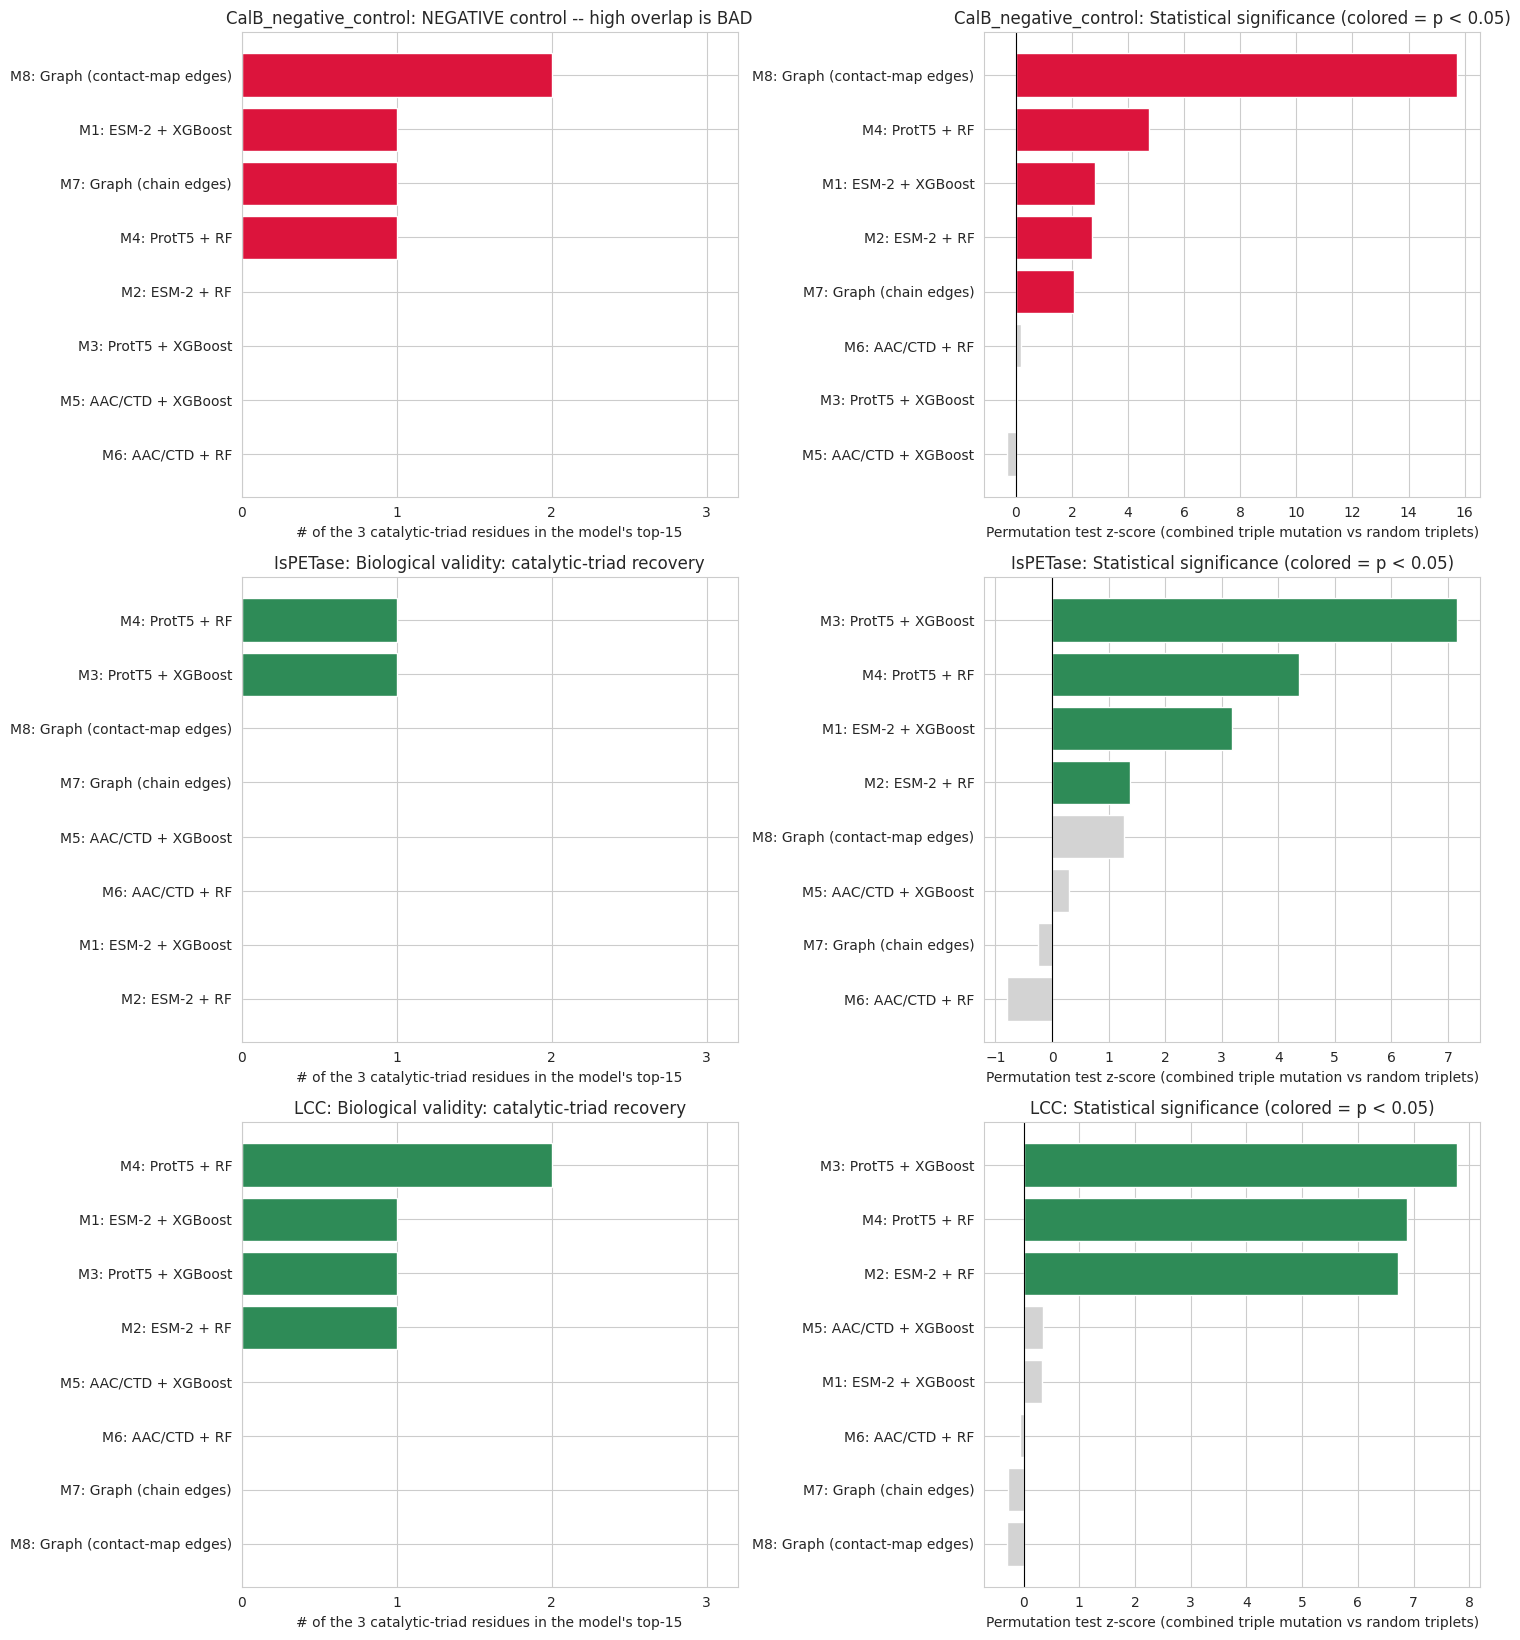

In [17]:
#@title # 15. Mutagenesis comparison -- charts (faceted by reference sequence)
if not master_mutagenesis_df.empty:
    refs = master_mutagenesis_df["reference"].unique()
    fig, axes = plt.subplots(len(refs), 2, figsize=(15, 5.5 * len(refs)))
    if len(refs) == 1:
        axes = axes.reshape(1, -1)

    for row_i, ref_name in enumerate(refs):
        sub = master_mutagenesis_df[master_mutagenesis_df["reference"] == ref_name]
        is_neg = not sub["is_positive_control"].iloc[0]

        order = sub.sort_values("top15_overlap_with_triad")
        bar_color = "crimson" if is_neg else "seagreen"
        axes[row_i, 0].barh(order["model"], order["top15_overlap_with_triad"], color=bar_color)
        axes[row_i, 0].set_xlabel("# of the 3 catalytic-triad residues in the model's top-15")
        label = "NEGATIVE control -- high overlap is BAD" if is_neg else "Biological validity: catalytic-triad recovery"
        axes[row_i, 0].set_title(f"{ref_name}: {label}")
        axes[row_i, 0].set_xlim(0, 3.2)
        axes[row_i, 0].set_xticks([0, 1, 2, 3])

        order2 = sub.sort_values("permutation_z_score")
        colors = [("crimson" if is_neg else "seagreen") if p < 0.05 else "lightgray"
                  for p in order2["permutation_p_value"]]
        axes[row_i, 1].barh(order2["model"], order2["permutation_z_score"], color=colors)
        axes[row_i, 1].set_xlabel("Permutation test z-score (combined triple mutation vs random triplets)")
        axes[row_i, 1].set_title(f"{ref_name}: Statistical significance (colored = p < 0.05)")
        axes[row_i, 1].axvline(0, color="black", linewidth=0.8)

    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_OUT_DIR, "mutagenesis_comparison_charts.png"), dpi=150)
    plt.show()
else:
    print("No reference_mutagenesis_results.pkl files found yet for any model.")

In [18]:
#@title # 16. Error analysis -- compiled comparison
err_rows = []
for m in MODELS:
    detailed = load_csv(m, "benchmark_predictions_detailed.csv")
    if detailed is None:
        continue
    fp = ((detailed["label"] == 0) & (detailed["pred_label"] == 1)).sum()
    fn = ((detailed["label"] == 1) & (detailed["pred_label"] == 0)).sum()
    tp = ((detailed["label"] == 1) & (detailed["pred_label"] == 1)).sum()
    tn = ((detailed["label"] == 0) & (detailed["pred_label"] == 0)).sum()
    err_rows.append({
        "model": m["label"],
        "benchmark_n": len(detailed),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "mean_seq_len": detailed["seq_len"].mean() if "seq_len" in detailed.columns else np.nan,
    })

master_error_df = pd.DataFrame(err_rows)
master_error_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_error_analysis.csv"), index=False)
master_error_df


,model,benchmark_n,TP,FP,FN,TN,mean_seq_len
0,M1: ESM-2 + XGBoost,139,21,3,1,114,324.395683
1,M2: ESM-2 + RF,139,22,12,0,105,324.395683
2,M3: ProtT5 + XGBoost,139,22,13,0,104,324.395683
3,M4: ProtT5 + RF,139,22,9,0,108,324.395683
4,M5: AAC/CTD + XGBoost,139,19,8,3,109,324.395683
5,M6: AAC/CTD + RF,139,19,11,3,106,324.395683
6,M7: Graph (chain edges),139,21,4,1,113,310.366906
7,M8: Graph (contact-map edges),139,21,7,1,110,310.366906


In [19]:
#@title # 17. Master ranking table (composite score across all criteria)
ranking_df = master_benchmark_df[["model", "f1", "auc", "pr_auc", "mcc"]].copy()

if not master_mutagenesis_df.empty:
    # Positive-control criterion: MEAN catalytic-triad overlap across
    # IsPETase + LCC (generalization across independent PETase sequences).
    pos_ctrl = master_mutagenesis_df[master_mutagenesis_df["is_positive_control"]]
    pos_summary = pos_ctrl.groupby("model").agg(
        mean_triad_overlap=("top15_overlap_with_triad", "mean"),
        mean_permutation_z=("permutation_z_score", "mean"),
    ).reset_index()

    ranking_df = ranking_df.merge(pos_summary, on="model", how="left")

    # Negative-control criterion (specificity): reported, NOT ranked in the
    # same direction -- attach as a separate diagnostic column.
    neg_ctrl = master_mutagenesis_df[~master_mutagenesis_df["is_positive_control"]]
    if not neg_ctrl.empty:
        neg_summary = neg_ctrl.groupby("model")["top15_overlap_with_triad"].mean().reset_index()
        neg_summary.columns = ["model", "calb_negative_control_overlap"]
        ranking_df = ranking_df.merge(neg_summary, on="model", how="left")

rank_cols = [c for c in ["f1", "auc", "pr_auc", "mcc", "mean_triad_overlap", "mean_permutation_z"]
             if c in ranking_df.columns]
for c in rank_cols:
    ranking_df[f"rank_{c}"] = ranking_df[c].rank(ascending=False, method="min")

rank_rank_cols = [f"rank_{c}" for c in rank_cols]
ranking_df["avg_rank"] = ranking_df[rank_rank_cols].mean(axis=1)
ranking_df = ranking_df.sort_values("avg_rank").reset_index(drop=True)
ranking_df.insert(0, "overall_rank", range(1, len(ranking_df) + 1))

ranking_df.to_csv(os.path.join(COMPARISON_OUT_DIR, "master_ranking.csv"), index=False)
ranking_df

,overall_rank,model,f1,auc,pr_auc,mcc,mean_triad_overlap,mean_permutation_z,calb_negative_control_overlap,rank_f1,rank_auc,rank_pr_auc,rank_mcc,rank_mean_triad_overlap,rank_mean_permutation_z,avg_rank
0,1,M1: ESM-2 + XGBoost,0.913043,0.986791,0.904782,0.897058,0.5,1.758897,1.0,1.0,1.0,1.0,1.0,3.0,4.0,1.833333
1,2,M4: ProtT5 + RF,0.830189,0.981352,0.845946,0.809374,1.5,5.626946,1.0,4.0,4.0,4.0,4.0,1.0,2.0,3.166667
2,3,M2: ESM-2 + RF,0.785714,0.984848,0.874549,0.762033,0.5,4.048603,0.0,5.0,2.0,2.0,5.0,3.0,3.0,3.333333
3,4,M7: Graph (chain edges),0.893617,0.982517,0.854758,0.874658,0.0,-0.268231,1.0,2.0,3.0,3.0,2.0,5.0,7.0,3.666667
4,5,M3: ProtT5 + XGBoost,0.771930,0.981352,0.827719,0.747483,1.0,7.478632,0.0,7.0,4.0,5.0,6.0,2.0,1.0,4.166667
5,6,M8: Graph (contact-map edges),0.840000,0.954157,0.640703,0.814234,0.0,0.483351,2.0,3.0,7.0,8.0,3.0,5.0,5.0,5.166667
6,7,M5: AAC/CTD + XGBoost,0.775510,0.965812,0.774149,0.733707,0.0,0.323950,0.0,6.0,6.0,6.0,7.0,5.0,6.0,6.000000
7,8,M6: AAC/CTD + RF,0.730769,0.951437,0.715595,0.682820,0.0,-0.427764,0.0,8.0,8.0,7.0,8.0,5.0,8.0,7.333333


In [20]:
#@title # 18. Conclusion (auto-generated from the compiled results above)
# Every sentence below is generated FROM the tables computed above -- if you
# re-run this notebook after more training/tuning, the conclusion updates
# with it. Nothing here is hardcoded.

lines = []
lines.append("=" * 78)
lines.append("INTERPET ABLATION STUDY -- SUMMARY & CONCLUSION")
lines.append("=" * 78)

if not ranking_df.empty:
    best = ranking_df.iloc[0]
    lines.append(f"\nBest overall model (composite rank across F1/AUC/PR-AUC/MCC + mutagenesis "
                 f"biological validity): {best['model']} (avg rank {best['avg_rank']:.2f}).")

if not master_benchmark_df.empty:
    top_f1 = master_benchmark_df.iloc[0]
    bn = top_f1["benchmark_n"]
    bn_str = str(int(bn)) if pd.notna(bn) else "?"
    lines.append(f"\nHighest benchmark F1: {top_f1['model']} (F1={top_f1['f1']:.3f}, "
                 f"AUC={top_f1['auc']:.3f}, MCC={top_f1['mcc']:.3f}, n_benchmark={bn_str}).")

    top_auc = master_benchmark_df.sort_values("auc", ascending=False).iloc[0]
    if top_auc["model"] != top_f1["model"]:
        lines.append(f"Highest benchmark AUC: {top_auc['model']} (AUC={top_auc['auc']:.3f}) -- "
                     f"a different model than the F1 leader, so ranking depends somewhat on which "
                     f"metric matters more for the intended use case.")

    fam_means = master_benchmark_df.groupby("family")[["f1", "auc"]].mean().sort_values("f1", ascending=False)
    lines.append("\nAverage benchmark performance by representation family:")
    for fam, r in fam_means.iterrows():
        lines.append(f"  {fam:<20s} mean F1={r['f1']:.3f}, mean AUC={r['auc']:.3f}")

    tabular = master_benchmark_df[master_benchmark_df["family"] != "Graph"]
    if not tabular.empty:
        algo_means = tabular.groupby("algorithm")[["f1", "auc"]].mean()
        lines.append("\nXGBoost vs Random Forest (averaged across ESM-2/ProtT5/AAC-CTD representations):")
        for algo, r in algo_means.iterrows():
            lines.append(f"  {algo:<15s} mean F1={r['f1']:.3f}, mean AUC={r['auc']:.3f}")

if not master_mutagenesis_df.empty:
    pos_ctrl = master_mutagenesis_df[master_mutagenesis_df["is_positive_control"]]
    best_bio_row = pos_ctrl.loc[pos_ctrl.groupby("model")["top15_overlap_with_triad"].transform("mean").idxmax()]
    lines.append(f"\nBest biological validity (mean catalytic-triad recovery across IsPETase + LCC): "
                 f"{best_bio_row['model']}.")

    n_sig_pos = (pos_ctrl["permutation_p_value"] < 0.05).sum()
    lines.append(f"{n_sig_pos}/{len(pos_ctrl)} model-reference pairs (positive controls) show a "
                 f"statistically significant (p<0.05) combined-mutation effect at the catalytic triad.")

    neg_ctrl = master_mutagenesis_df[~master_mutagenesis_df["is_positive_control"]]
    if not neg_ctrl.empty:
        n_sig_neg = (neg_ctrl["permutation_p_value"] < 0.05).sum()
        specificity_note = ("a concerning sign that importance signal may not be PET-specific."
                            if n_sig_neg > 0 else
                            "suggesting importance signal is reasonably specific to PET-degrading enzymes.")
        lines.append(f"\nSpecificity check (CalB negative control): {n_sig_neg}/{len(neg_ctrl)} models "
                    f"showed a significant combined-mutation effect at CalB's (PETase-irrelevant) "
                    f"catalytic site -- {specificity_note}")

if not master_benchmark_df.empty:
    graph_rows = master_benchmark_df[master_benchmark_df["family"] == "Graph"]
    non_graph_rows = master_benchmark_df[master_benchmark_df["family"] != "Graph"]
    if not graph_rows.empty and not non_graph_rows.empty:
        graph_f1 = graph_rows["f1"].mean()
        non_graph_f1 = non_graph_rows["f1"].mean()
        direction = "outperform" if graph_f1 > non_graph_f1 else "underperform"
        lines.append(f"\nGraph-based models (#7/#8, mean F1={graph_f1:.3f}) {direction} the tabular "
                     f"1D models (#1-6, mean F1={non_graph_f1:.3f}) on average -- but keep in mind #7/#8 "
                     f"are evaluated on a smaller, structure-matched benchmark subset (see the caveat in "
                     f"section 1), so this is directional, not strictly apples-to-apples.")

    m7 = master_benchmark_df[master_benchmark_df["model"].str.startswith("M7")]
    m8 = master_benchmark_df[master_benchmark_df["model"].str.startswith("M8")]
    if not m7.empty and not m8.empty:
        f1_7, f1_8 = m7.iloc[0]["f1"], m8.iloc[0]["f1"]
        better = "structure contact-map edges (#8)" if f1_8 > f1_7 else "sequence chain edges (#7)"
        signal_note = "3D structural contacts add useful signal beyond" if f1_8 > f1_7 else "the extra 3D structural-contact edges do not clearly beat"
        lines.append(f"\nWithin the graph family (apples-to-apples, same benchmark subset, same node "
                     f"features): {better} gives the better benchmark F1 "
                     f"(M7 F1={f1_7:.3f} vs M8 F1={f1_8:.3f}), suggesting {signal_note} "
                     f"simple sequence adjacency for this task.")

lines.append("\n" + "=" * 78)
lines.append("Full detail for every claim above is in the tables/charts in sections 3-17,")
lines.append(f"and in the Excel workbook exported to:\n  {COMPARISON_OUT_DIR}/model_comparison_all.xlsx")
lines.append("=" * 78)

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(os.path.join(COMPARISON_OUT_DIR, "conclusion.txt"), "w") as f:
    f.write(conclusion_text)


INTERPET ABLATION STUDY -- SUMMARY & CONCLUSION

Best overall model (composite rank across F1/AUC/PR-AUC/MCC + mutagenesis biological validity): M1: ESM-2 + XGBoost (avg rank 1.83).

Highest benchmark F1: M1: ESM-2 + XGBoost (F1=0.913, AUC=0.987, MCC=0.897, n_benchmark=139).

Average benchmark performance by representation family:
  Graph                mean F1=0.867, mean AUC=0.968
  1D embedding         mean F1=0.825, mean AUC=0.984
  1D handcrafted       mean F1=0.753, mean AUC=0.959

XGBoost vs Random Forest (averaged across ESM-2/ProtT5/AAC-CTD representations):
  Random Forest   mean F1=0.782, mean AUC=0.973
  XGBoost         mean F1=0.820, mean AUC=0.978

Best biological validity (mean catalytic-triad recovery across IsPETase + LCC): M4: ProtT5 + RF.
7/16 model-reference pairs (positive controls) show a statistically significant (p<0.05) combined-mutation effect at the catalytic triad.

Specificity check (CalB negative control): 5/8 models showed a significant combined-mutation 

In [21]:
#@title # 19. Export everything to one Excel workbook
excel_path = os.path.join(COMPARISON_OUT_DIR, "model_comparison_all.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    (ranking_df if "ranking_df" in dir() else pd.DataFrame()).to_excel(writer, sheet_name="ranking", index=False)
    master_benchmark_df.to_excel(writer, sheet_name="benchmark_metrics", index=False)

    if "master_ci_df" in dir() and not master_ci_df.empty:
        master_ci_df.to_excel(writer, sheet_name="bootstrap_ci", index=False)

    if "master_cv_df" in dir() and not master_cv_df.empty:
        master_cv_df.to_excel(writer, sheet_name="cv_fold_metrics", index=False)

    if "hp_summary_df" in dir() and not hp_summary_df.empty:
        hp_summary_df.to_excel(writer, sheet_name="hyperparam_search", index=False)

    if "master_shap_df" in dir() and not master_shap_df.empty:
        master_shap_df.to_excel(writer, sheet_name="shap_top5", index=False)

    if "cross_repr_summary_df" in dir() and not cross_repr_summary_df.empty:
        cross_repr_summary_df.to_excel(writer, sheet_name="cross_repr_summary", index=False)

    if "master_mutagenesis_df" in dir() and not master_mutagenesis_df.empty:
        master_mutagenesis_df.to_excel(writer, sheet_name="mutagenesis_reference_scan", index=False)

    if "master_error_df" in dir() and not master_error_df.empty:
        master_error_df.to_excel(writer, sheet_name="error_analysis", index=False)

    pd.DataFrame({"conclusion": conclusion_text.split("\n")}).to_excel(writer, sheet_name="conclusion", index=False)

print(f"Saved Excel workbook to {excel_path}")
print(f"\nAll comparison outputs (CSVs, PNGs, the Excel workbook, conclusion.txt) are in:\n  {COMPARISON_OUT_DIR}")


Saved Excel workbook to /content/drive/MyDrive/InterPET/models/comparison_all_models/model_comparison_all.xlsx

All comparison outputs (CSVs, PNGs, the Excel workbook, conclusion.txt) are in:
  /content/drive/MyDrive/InterPET/models/comparison_all_models
